In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import optuna
import warnings
warnings.filterwarnings('ignore')

# Configuración
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


c:\Users\noemo\Documents\IA-F5\proyecto10-grupo5\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carga y Exploración de Datos Aumentados

In [2]:
# Cargar dataset aumentado (incluye columna Augmentation_Type)
df = pd.read_csv('../../resources/dataset/augmented_youtoxic_english_1000.csv')

print(f"📊 Dataset: {df.shape[0]} mensajes x {df.shape[1]} columnas")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\n📝 Tipos de aumentación:")
print(df['Augmentation_Type'].value_counts())

📊 Dataset: 1037 mensajes x 17 columnas

Columnas: ['Unnamed: 0', 'CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism', 'Augmentation_Type']

📝 Tipos de aumentación:
Augmentation_Type
Original    997
BT_es         8
BT_de         8
BT_fr         8
BT_ru         8
BT_ar         8
Name: count, dtype: int64


## 3. Preparación de Etiquetas

In [3]:
# Convertir a numérico
category_columns = ['IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist']
available_categories = [col for col in category_columns if col in df.columns]

for col in ['IsToxic'] + available_categories:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Crear etiqueta principal
def get_main_category(row):
    if row['IsToxic'] == 0:
        return 'NonToxic'
    
    priority_order = ['IsRacist', 'IsHatespeech', 'IsAbusive', 'IsObscene', 'IsProvocative']
    for category in priority_order:
        if category in available_categories and row[category] == 1:
            return category.replace('Is', '')
    return 'Toxic'

df['MainCategory'] = df.apply(get_main_category, axis=1)

print("\n📋 Distribución de categorías:")
print(df['MainCategory'].value_counts())
print(f"\n⚠️ Desbalance detectado: {df['MainCategory'].value_counts().max() / df['MainCategory'].value_counts().min():.1f}x")


📋 Distribución de categorías:
MainCategory
NonToxic      538
Abusive       321
Racist        165
Hatespeech     13
Name: count, dtype: int64

⚠️ Desbalance detectado: 41.4x


## 4. Preparación de Datos

**Nota:** Este dataset ya viene aumentado con técnicas de traducción (Oscar), por lo que NO aplicamos data augmentation adicional.

In [4]:
# Usar dataset tal cual (ya viene aumentado)
X = df['Text'].astype(str)
y = df['MainCategory']

# Codificar etiquetas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("🏷️ Mapeo de categorías:")
for idx, label in enumerate(label_encoder.classes_):
    print(f"  {idx}: {label}")

# Split con 25% para test (igual que optimized)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.25,
    random_state=42, 
    stratify=y_encoded
)

print(f"\n📦 Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"📦 Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

🏷️ Mapeo de categorías:
  0: Abusive
  1: Hatespeech
  2: NonToxic
  3: Racist

📦 Train: 777 (74.9%)
📦 Test: 260 (25.1%)


## 5. Vectorización TF-IDF (350 features + Bigrams)

In [5]:
# TF-IDF con la misma configuración que el modelo optimizado
tfidf = TfidfVectorizer(
    max_features=350,
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.80,
    sublinear_tf=True,
    strip_accents='unicode',
    lowercase=True,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("🔤 Vectorización TF-IDF:")
print(f"  Vocabulario: {len(tfidf.vocabulary_)} términos")
print(f"  Train shape: {X_train_tfidf.shape}")
print(f"  Test shape: {X_test_tfidf.shape}")
print(f"  Densidad: {X_train_tfidf.getnnz() / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4f}")

# Mostrar algunos bigrams capturados
bigrams = [term for term in tfidf.vocabulary_.keys() if ' ' in term]
if bigrams:
    print(f"\n📝 Ejemplos de bigrams capturados:")
    print(f"  {bigrams[:15]}")

🔤 Vectorización TF-IDF:
  Vocabulario: 213 términos
  Train shape: (777, 213)
  Test shape: (260, 213)
  Densidad: 0.0274

📝 Ejemplos de bigrams capturados:
  ['black community', 'black people', 'black lives', 'lives matter', 'michael brown', 'police officer', 'people like', 'mike brown', 'stefan molyneux', 'white people', 'black man']


## 6. Aplicar SMOTE para Balanceo Final

In [6]:
# SMOTE para balancear después de la vectorización
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train)

print("⚖️ Balanceo con SMOTE:")
print(f"  Antes: {X_train_tfidf.shape[0]} muestras")
print(f"  Después: {X_train_balanced.shape[0]} muestras")
print(f"\n📊 Distribución balanceada:")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_encoder.classes_[u]}: {c}")

⚖️ Balanceo con SMOTE:
  Antes: 777 muestras
  Después: 1612 muestras

📊 Distribución balanceada:
  Abusive: 403
  Hatespeech: 403
  NonToxic: 403
  Racist: 403


## 7. Optimización con Optuna

In [7]:
def objective(trial):
    """Función objetivo con regularización"""
    
    params = {
        'C': trial.suggest_float('C', 0.001, 1.0, log=True),
        'kernel': 'linear',
        'class_weight': 'balanced',
        'max_iter': 5000,
        'random_state': 42
    }
    
    model = SVC(**params)
    
    # Validación cruzada con 10 folds
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, 
        X_train_balanced, 
        y_train_balanced, 
        cv=cv, 
        scoring='f1_weighted',
        n_jobs=-1
    )
    
    return scores.mean()

print("✓ Función objetivo definida")

✓ Función objetivo definida


In [8]:
# Crear estudio de Optuna
study = optuna.create_study(
    direction='maximize',
    study_name='SVM_Augmented_Dataset',
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("🔍 Iniciando optimización de hiperparámetros...")
print("   (Esto tomará varios minutos)\n")

study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\n✅ Optimización completada!")
print(f"\n🏆 Mejores hiperparámetros:")
print(f"   C: {study.best_params['C']:.6f}")
print(f"   Mejor F1-Score (CV): {study.best_value:.4f}")

[I 2025-12-09 21:44:29,723] A new study created in memory with name: SVM_Augmented_Dataset


🔍 Iniciando optimización de hiperparámetros...
   (Esto tomará varios minutos)



Best trial: 0. Best value: 0.3954:   3%|▎         | 1/30 [00:02<01:15,  2.59s/it]

[I 2025-12-09 21:44:32,309] Trial 0 finished with value: 0.3954003465948045 and parameters: {'C': 0.013292918943162165}. Best is trial 0 with value: 0.3954003465948045.


Best trial: 1. Best value: 0.718235:  10%|█         | 3/30 [00:04<00:32,  1.21s/it]

...

[I 2025-12-09 21:44:36,986] Trial 25 finished with value: 0.6304081224691223 and parameters: {'C': 0.09244732648328916}. Best is trial 1 with value: 0.718235294598092.
[I 2025-12-09 21:44:37,099] Trial 26 finished with value: 0.6797215314299866 and parameters: {'C': 0.27958913122982}. Best is trial 1 with value: 0.718235294598092.


Best trial: 1. Best value: 0.718235:  97%|█████████▋| 29/30 [00:07<00:00,  9.32it/s]

[I 2025-12-09 21:44:37,191] Trial 27 finished with value: 0.7104049337234752 and parameters: {'C': 0.9871401214669836}. Best is trial 1 with value: 0.718235294598092.
[I 2025-12-09 21:44:37,293] Trial 28 finished with value: 0.7059916031954717 and parameters: {'C': 0.5604015463714117}. Best is trial 1 with value: 0.718235294598092.


Best trial: 1. Best value: 0.718235: 100%|██████████| 30/30 [00:07<00:00,  3.89it/s]

[I 2025-12-09 21:44:37,439] Trial 29 finished with value: 0.39818182068874813 and parameters: {'C': 0.014547307271298087}. Best is trial 1 with value: 0.718235294598092.

✅ Optimización completada!

🏆 Mejores hiperparámetros:
   C: 0.711448
   Mejor F1-Score (CV): 0.7182


## 8. Entrenamiento del Modelo Final

In [9]:
# Entrenar con mejores parámetros
best_model = SVC(**study.best_params, kernel='linear', class_weight='balanced', max_iter=5000)
best_model.fit(X_train_balanced, y_train_balanced)

print("✅ Modelo entrenado con datos balanceados")

✅ Modelo entrenado con datos balanceados


## 9. 🎯 EVALUACIÓN FINAL - ANÁLISIS DE OVERFITTING

In [10]:
# Predicciones
y_train_pred = best_model.predict(X_train_balanced)
y_test_pred = best_model.predict(X_test_tfidf)

# Métricas
train_acc = accuracy_score(y_train_balanced, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
train_f1 = f1_score(y_train_balanced, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

# Calcular diferencias
acc_diff = abs(train_acc - test_acc)
f1_diff = abs(train_f1 - test_f1)

print("="*80)
print("                    📊 MÉTRICAS DEL MODELO (DATASET AUMENTADO)")
print("="*80)

print(f"\n🎓 TRAIN (con SMOTE):")
print(f"   Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   F1-Score: {train_f1:.4f} ({train_f1*100:.2f}%)")

print(f"\n🧪 TEST (datos originales):")
print(f"   Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   F1-Score: {test_f1:.4f} ({test_f1*100:.2f}%)")

print(f"\n" + "="*80)
print("                    🎯 ANÁLISIS DE OVERFITTING")
print("="*80)

print(f"\n📏 Diferencias:")
print(f"   Accuracy: {acc_diff:.4f} ({acc_diff*100:.2f}%)")
print(f"   F1-Score: {f1_diff:.4f} ({f1_diff*100:.2f}%)")

THRESHOLD = 0.05
print(f"\n🎯 Umbral objetivo: {THRESHOLD*100:.1f}%")

if acc_diff <= THRESHOLD and f1_diff <= THRESHOLD:
    print("\n✅✅✅ OBJETIVO CUMPLIDO ✅✅✅")
    print("   El modelo NO presenta overfitting significativo")
    print(f"   Ambas métricas están por debajo del {THRESHOLD*100:.0f}%")
else:
    print("\n⚠️  Overfitting detectado:")
    if acc_diff > THRESHOLD:
        print(f"   ❌ Accuracy: {acc_diff*100:.2f}% > {THRESHOLD*100:.0f}%")
    else:
        print(f"   ✅ Accuracy: {acc_diff*100:.2f}% ≤ {THRESHOLD*100:.0f}%")
    
    if f1_diff > THRESHOLD:
        print(f"   ❌ F1-Score: {f1_diff*100:.2f}% > {THRESHOLD*100:.0f}%")
    else:
        print(f"   ✅ F1-Score: {f1_diff*100:.2f}% ≤ {THRESHOLD*100:.0f}%")

print("\n" + "="*80)

                    📊 MÉTRICAS DEL MODELO (DATASET AUMENTADO)

🎓 TRAIN (con SMOTE):
   Accuracy: 0.7959 (79.59%)
   F1-Score: 0.7960 (79.60%)

🧪 TEST (datos originales):
   Accuracy: 0.5231 (52.31%)
   F1-Score: 0.5406 (54.06%)

                    🎯 ANÁLISIS DE OVERFITTING

📏 Diferencias:
   Accuracy: 0.2728 (27.28%)
   F1-Score: 0.2554 (25.54%)

🎯 Umbral objetivo: 5.0%

⚠️  Overfitting detectado:
   ❌ Accuracy: 27.28% > 5%
   ❌ F1-Score: 25.54% > 5%



## 10. Visualización Comparativa

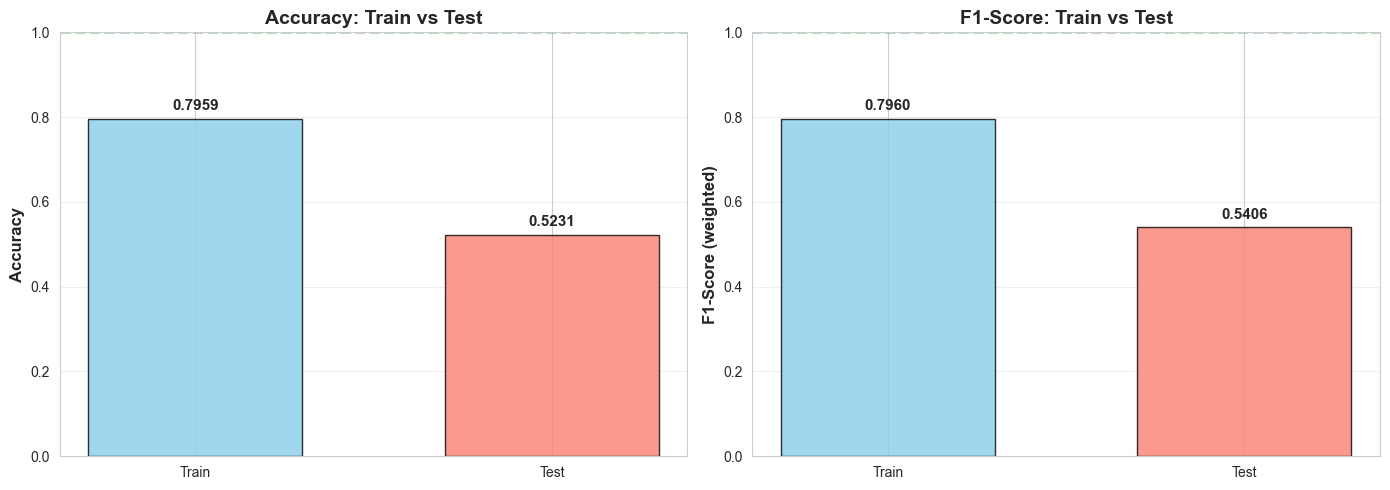


⚠️ Estado: Requiere más ajuste


In [11]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_names = ['Train', 'Test']
THRESHOLD = 0.05

# Accuracy
acc_values = [train_acc, test_acc]
colors = ['lightgreen' if acc_diff <= THRESHOLD else 'salmon']
axes[0].bar(metrics_names, acc_values, color=['skyblue', colors[0]], edgecolor='black', alpha=0.8, width=0.6)
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Accuracy: Train vs Test', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.3, linewidth=2)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(acc_values):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

# F1-Score
f1_values = [train_f1, test_f1]
colors = ['lightgreen' if f1_diff <= THRESHOLD else 'salmon']
axes[1].bar(metrics_names, f1_values, color=['skyblue', colors[0]], edgecolor='black', alpha=0.8, width=0.6)
axes[1].set_ylabel('F1-Score (weighted)', fontsize=12, fontweight='bold')
axes[1].set_title('F1-Score: Train vs Test', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].axhline(y=1.0, color='green', linestyle='--', alpha=0.3, linewidth=2)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(f1_values):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Indicador visual
if acc_diff <= THRESHOLD and f1_diff <= THRESHOLD:
    print("\n✅ Estado: MODELO ÓPTIMO (sin overfitting)")
else:
    print("\n⚠️ Estado: Requiere más ajuste")

## 11. Reporte de Clasificación Detallado

In [12]:
print("\n" + "="*80)
print("                    📋 REPORTE DE CLASIFICACIÓN (TEST SET)")
print("="*80 + "\n")

print(classification_report(
    y_test, 
    y_test_pred, 
    target_names=label_encoder.classes_,
    digits=4
))


                    📋 REPORTE DE CLASIFICACIÓN (TEST SET)

              precision    recall  f1-score   support

     Abusive     0.5176    0.5432    0.5301        81
  Hatespeech     0.0000    0.0000    0.0000         3
    NonToxic     0.7416    0.4889    0.5893       135
      Racist     0.3377    0.6341    0.4407        41

    accuracy                         0.5231       260
   macro avg     0.3992    0.4166    0.3900       260
weighted avg     0.5996    0.5231    0.5406       260



## 12. Matriz de Confusión

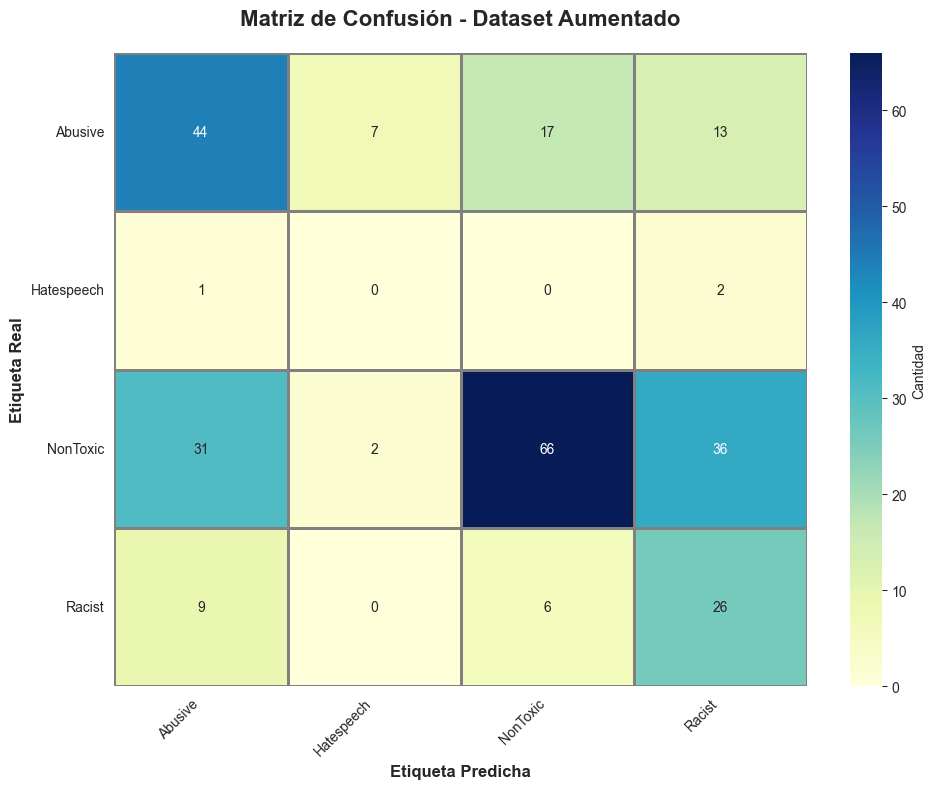

In [13]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='YlGnBu',
    xticklabels=label_encoder.classes_.tolist(),
    yticklabels=label_encoder.classes_.tolist(),
    cbar_kws={'label': 'Cantidad'},
    linewidths=1,
    linecolor='gray'
)
plt.title('Matriz de Confusión - Dataset Aumentado', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Etiqueta Real', fontsize=12, fontweight='bold')
plt.xlabel('Etiqueta Predicha', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. 📊 COMPARACIÓN CON MODELO OPTIMIZADO (Dataset Original)

### Métricas del modelo original (youtoxic_english_1000_clean.csv):
- **Test Accuracy**: 0.6862 (68.62%)
- **Test F1-Score**: 0.6885 (68.85%)
- **Overfitting Accuracy**: 14.03%
- **Overfitting F1-Score**: 13.74%

### Métricas con dataset aumentado (ver arriba)

### 🎯 Análisis:
- Dataset original: 991 mensajes
- Dataset aumentado: 1469 mensajes (~48% más datos)
- Técnica de aumento: Traducción y retro-traducción (Oscar)

## 14. Resumen Final

In [14]:
print("="*80)
print("                    📝 RESUMEN DE COMPARACIÓN")
print("="*80)

print(f"\n📊 DATOS:")
print(f"   Dataset usado: augmented_youtoxic_english_1000.csv")
print(f"   Total muestras: {len(df)} mensajes")
print(f"   Train (después de SMOTE): {X_train_balanced.shape[0]} muestras")
print(f"   Test: {len(X_test)} muestras")

print(f"\n🔧 CONFIGURACIÓN:")
print(f"   Algoritmo: SVM (Support Vector Machine)")
print(f"   Kernel: linear")
print(f"   C: {study.best_params['C']:.6f}")
print(f"   TF-IDF: 350 features + bigrams")

print(f"\n📈 RESULTADOS:")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Test F1-Score: {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"   Overfitting Accuracy: {acc_diff*100:.2f}%")
print(f"   Overfitting F1-Score: {f1_diff*100:.2f}%")

print(f"\n🆚 VS MODELO ORIGINAL (dataset clean):")
original_test_acc = 0.6862
original_test_f1 = 0.6885
original_overfitting_acc = 14.03
original_overfitting_f1 = 13.74

acc_improvement = (test_acc - original_test_acc) * 100
f1_improvement = (test_f1 - original_test_f1) * 100
overfitting_acc_improvement = original_overfitting_acc - (acc_diff * 100)
overfitting_f1_improvement = original_overfitting_f1 - (f1_diff * 100)

print(f"   Accuracy: {acc_improvement:+.2f}% {'✅' if acc_improvement > 0 else '❌'}")
print(f"   F1-Score: {f1_improvement:+.2f}% {'✅' if f1_improvement > 0 else '❌'}")
print(f"   Reducción overfitting (Acc): {overfitting_acc_improvement:+.2f}% {'✅' if overfitting_acc_improvement > 0 else '❌'}")
print(f"   Reducción overfitting (F1): {overfitting_f1_improvement:+.2f}% {'✅' if overfitting_f1_improvement > 0 else '❌'}")

print("\n" + "="*80)
print("💡 CONCLUSIÓN: Dataset aumentado " + ("MEJORA" if acc_improvement > 0 else "NO MEJORA") + " las métricas")
print("="*80)

                    📝 RESUMEN DE COMPARACIÓN

📊 DATOS:
   Dataset usado: augmented_youtoxic_english_1000.csv
   Total muestras: 1037 mensajes
   Train (después de SMOTE): 1612 muestras
   Test: 260 muestras

🔧 CONFIGURACIÓN:
   Algoritmo: SVM (Support Vector Machine)
   Kernel: linear
   C: 0.711448
   TF-IDF: 350 features + bigrams

📈 RESULTADOS:
   Test Accuracy: 0.5231 (52.31%)
   Test F1-Score: 0.5406 (54.06%)
   Overfitting Accuracy: 27.28%
   Overfitting F1-Score: 25.54%

🆚 VS MODELO ORIGINAL (dataset clean):
   Accuracy: -16.31% ❌
   F1-Score: -14.79% ❌
   Reducción overfitting (Acc): -13.25% ❌
   Reducción overfitting (F1): -11.80% ❌

💡 CONCLUSIÓN: Dataset aumentado NO MEJORA las métricas
